In [1]:
import sys
path_to_pip_installs = "/tmp/test_env"
if path_to_pip_installs not in sys.path:
    sys.path.insert(0, path_to_pip_installs)

In [2]:
# Notebook helpers: import from your existing module
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from regnet import (
    load_model,
    MRIRegistrationDataset,
    infer_pair,
    apply_flow_to_mask,
)

import torch
from torch.utils.data import DataLoader


# ---- minimal I/O utils ----
def _ensure_2d(arr: np.ndarray) -> np.ndarray:
    """Return (H, W) view for display; accepts (H,W), (1,H,W), or (1,1,H,W)."""
    if arr.ndim == 2:
        return arr
    if arr.ndim == 3:
        return arr[0]
    if arr.ndim == 4:
        return arr[0, 0]
    raise ValueError(f"Unsupported array shape {arr.shape}")

def _zscore_np(img: np.ndarray) -> np.ndarray:
    img = img.astype(np.float32)
    std = float(img.std())
    if std < 1e-6:
        return np.zeros_like(img, dtype=np.float32)
    return (img - float(img.mean())) / (std + 1e-6)

def _to_1chw(x: np.ndarray) -> torch.Tensor:
    """Convert (H,W) or (1,H,W) or (1,1,H,W) numpy -> torch (1,1,H,W) float32."""
    if x.ndim == 2:
        x = x[None, None, ...]
    elif x.ndim == 3:
        x = x[None, ...]
    elif x.ndim == 4:
        pass
    else:
        raise ValueError(f"Unsupported shape {x.shape}")
    return torch.from_numpy(x.astype(np.float32))


# ---- quick visualization ----
def show_triplet(moving, fixed, warped, cmap="gray"):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(_ensure_2d(moving), cmap=cmap); axes[0].set_title("Moving"); axes[0].axis("off")
    axes[1].imshow(_ensure_2d(fixed),  cmap=cmap); axes[1].set_title("Fixed");  axes[1].axis("off")
    axes[2].imshow(_ensure_2d(warped), cmap=cmap); axes[2].set_title("Warped→Fixed"); axes[2].axis("off")
    plt.tight_layout(); plt.show()

def show_mask_on_fixed(fixed, mask, alpha=0.4):
    plt.figure(figsize=(5,5))
    plt.imshow(_ensure_2d(fixed), cmap="gray")
    plt.imshow(_ensure_2d(mask), alpha=alpha)
    plt.axis("off"); plt.title("Warped mask on fixed")
    plt.show()

def show_flow_quiver(flow, step=8):
    """flow: (2,H,W) or (1,2,H,W) in normalized coords."""
    if flow.ndim == 4:
        flow = flow[0]
    dx, dy = flow[0], flow[1]
    H, W = dx.shape
    mag = np.sqrt(dx**2 + dy**2)

    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    im0 = axes[0].imshow(mag); axes[0].set_title("Flow magnitude"); axes[0].axis("off"); fig.colorbar(im0, ax=axes[0])
    Y, X = np.mgrid[0:H:step, 0:W:step]
    axes[1].imshow(mag, alpha=0.3)
    axes[1].quiver(X, Y, dx[::step, ::step], dy[::step, ::step])
    axes[1].set_title("Flow quiver"); axes[1].axis("off")
    plt.tight_layout(); plt.show()


# ---- 1) Register a single pair and (optionally) warp a mask ----
def nb_register_pair(
    checkpoint: str,
    moving_slice: np.ndarray,
    fixed_slice: np.ndarray,
    mask_slice: np.ndarray | None = None,
    zscore: bool = True,
    device: str | None = None,
    visualize: bool = True,
):
    """
    Args:
      checkpoint: path to trained weights (e.g., 'outputs/registr_2d/best.pt')
      moving_slice, fixed_slice: numpy arrays of shape (H,W) or (1,H,W) or (1,1,H,W)
      mask_slice: optional integer label mask aligned with moving_slice
      zscore: per-image z-scoring before inference
      device: e.g. 'cuda' or 'cpu'; None = auto
      visualize: if True, show triplet, flow quiver, and mask overlay (when provided)

    Returns:
      warped_img: (H,W) float32
      flow: (2,H,W) float32 in normalized coords
      warped_mask (optional): (H,W) int64 if mask provided
    """
    # load model
    dev = torch.device(device) if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = load_model(checkpoint, device=dev)

    # prep inputs
    mv_np = moving_slice
    fx_np = fixed_slice
    if zscore:
        mv_np = _zscore_np(_ensure_2d(mv_np))
        fx_np = _zscore_np(_ensure_2d(fx_np))
    mv_t = _to_1chw(mv_np).to(dev)
    fx_t = _to_1chw(fx_np).to(dev)

    # inference
    with torch.no_grad():
        warped_t, flow_t = infer_pair(model, mv_t, fx_t)
    warped = warped_t.squeeze(0).squeeze(0).cpu().numpy()
    flow = flow_t.squeeze(0).cpu().numpy()  # (2,H,W)

    warped_mask = None
    if mask_slice is not None:
        mk = mask_slice
        if mk.ndim == 2:
            mk = mk[None, None, ...]
        elif mk.ndim == 3:
            mk = mk[None, ...]
        mk_t = torch.from_numpy(mk).long().to(dev)
        with torch.no_grad():
            warped_mask_t = apply_flow_to_mask(mk_t, flow_t)
        warped_mask = warped_mask_t.squeeze(0).squeeze(0).cpu().numpy()

    if visualize:
        show_triplet(_ensure_2d(moving_slice), _ensure_2d(fixed_slice), warped)
        show_flow_quiver(flow, step=10)
        if warped_mask is not None:
            show_mask_on_fixed(_ensure_2d(fixed_slice), warped_mask, alpha=0.4)

    return (warped, flow) if warped_mask is None else (warped, flow, warped_mask)


# ---- 2) Run inference over a dataset split and optionally preview a few ----
def nb_infer_split(
    checkpoint: str,
    data_root: str = "data/my_data2",
    split: str = "test",
    target: str = "DIXON",
    moving: str = "T1_mapping_fl2d",
    batch_size: int = 8,
    num_workers: int = 2,
    preview: int = 3,
    device: str | None = None,
):
    """
    Loads the split via MRIRegistrationDataset and returns stacked numpy arrays.
    Saves nothing; purely in-memory for notebook usage.

    Returns:
      warped_all: (N, H, W) float32
      flows_all:  (N, 2, H, W) float32
    """
    dev = torch.device(device) if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = load_model(checkpoint, device=dev)

    ds = MRIRegistrationDataset(data_root, split, target, moving, augment=False)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    warped_list, flow_list = [], []
    model.eval()
    with torch.no_grad():
        for mv, fx in loader:
            mv = mv.to(dev)
            fx = fx.to(dev)
            warped, flow = infer_pair(model, mv, fx)
            warped_list.append(warped.squeeze(1).cpu().numpy())   # (B,H,W)
            flow_list.append(flow.cpu().numpy())                  # (B,2,H,W)

    warped_all = np.concatenate(warped_list, axis=0)
    flows_all = np.concatenate(flow_list, axis=0)

    # quick preview
    for i in range(min(preview, len(ds))):
        moving_i, fixed_i = ds[i]  # tensors (1,H,W)
        show_triplet(moving_i.numpy()[0], fixed_i.numpy()[0], warped_all[i])
        show_flow_quiver(flows_all[i], step=10)

    return warped_all, flows_all



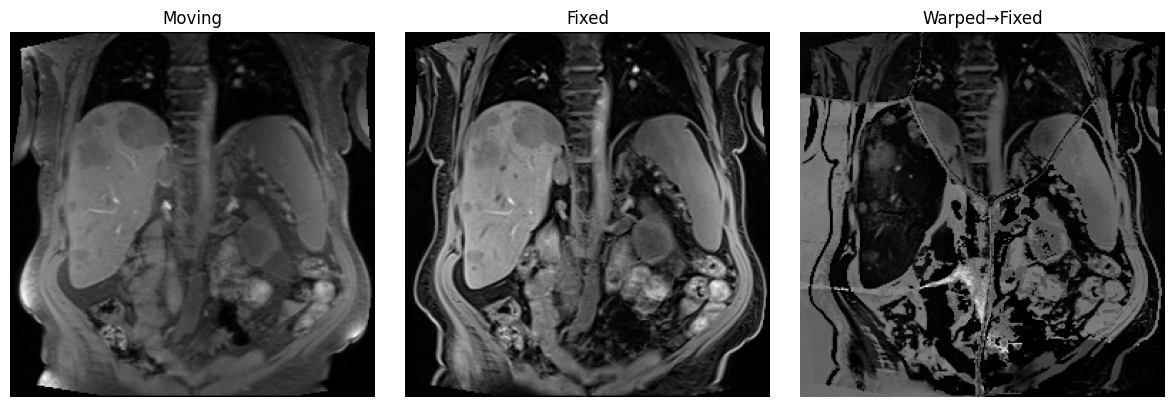

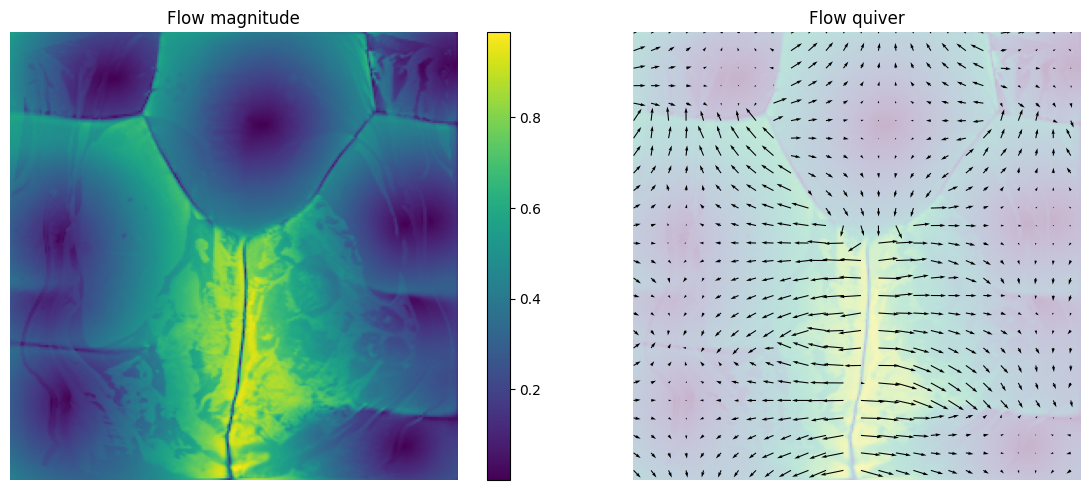

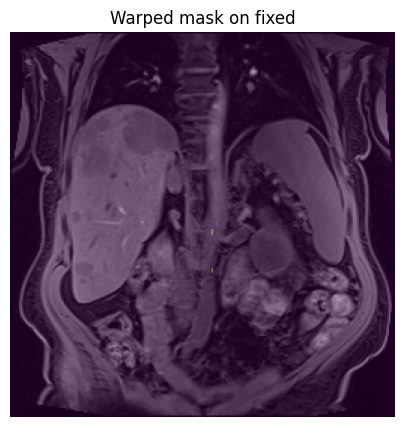

/tmp/test_env/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


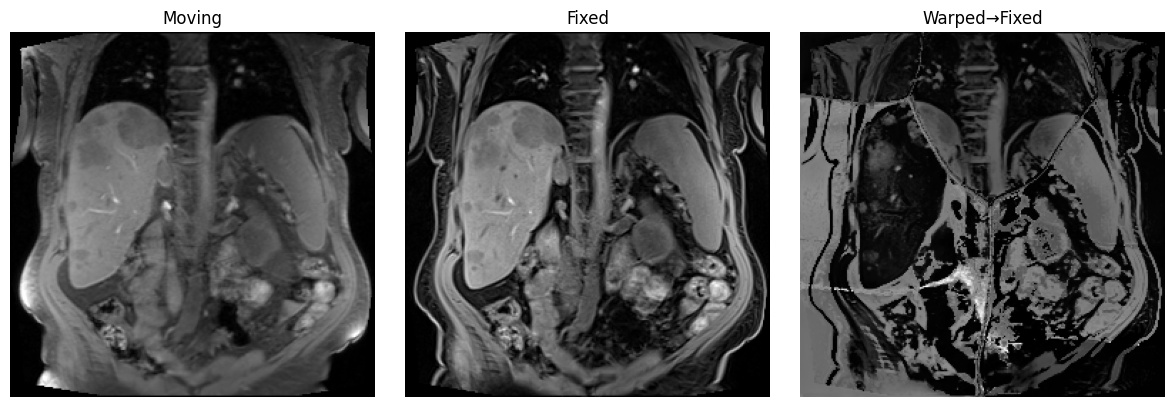

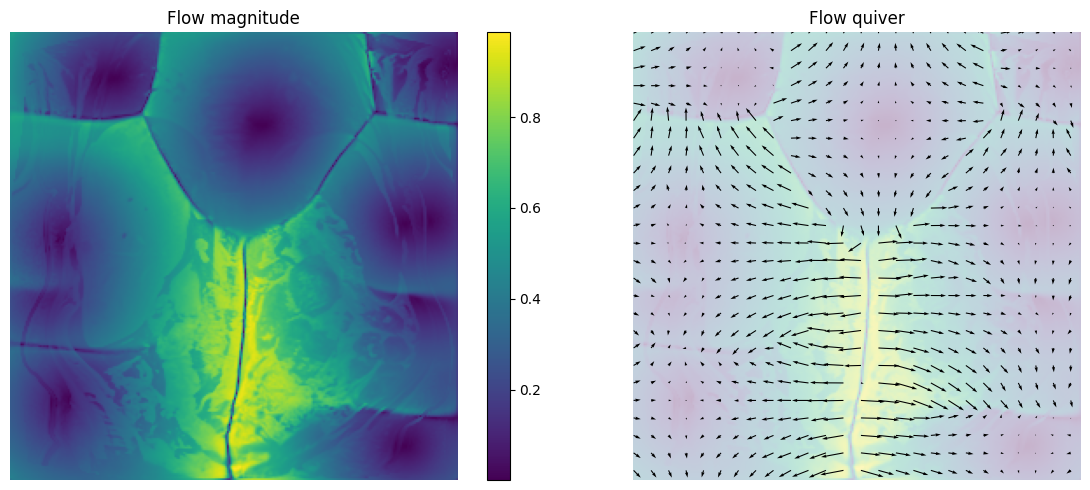

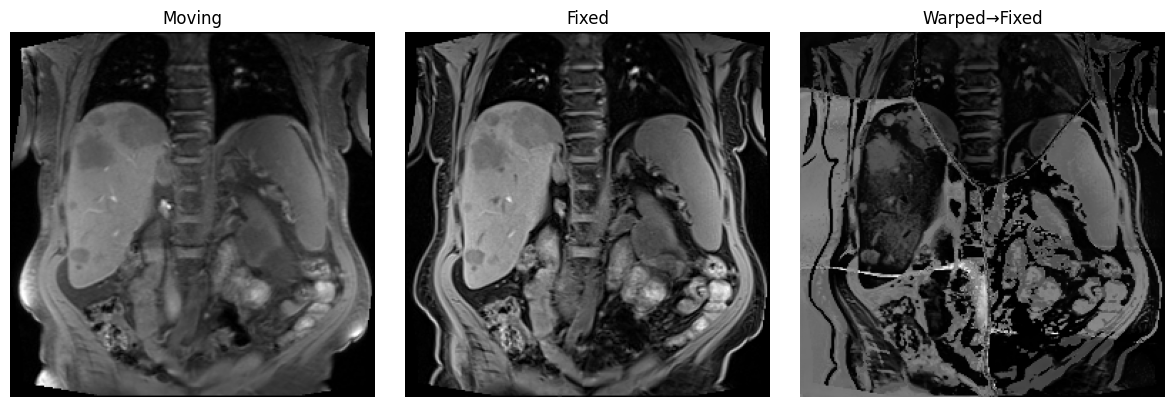

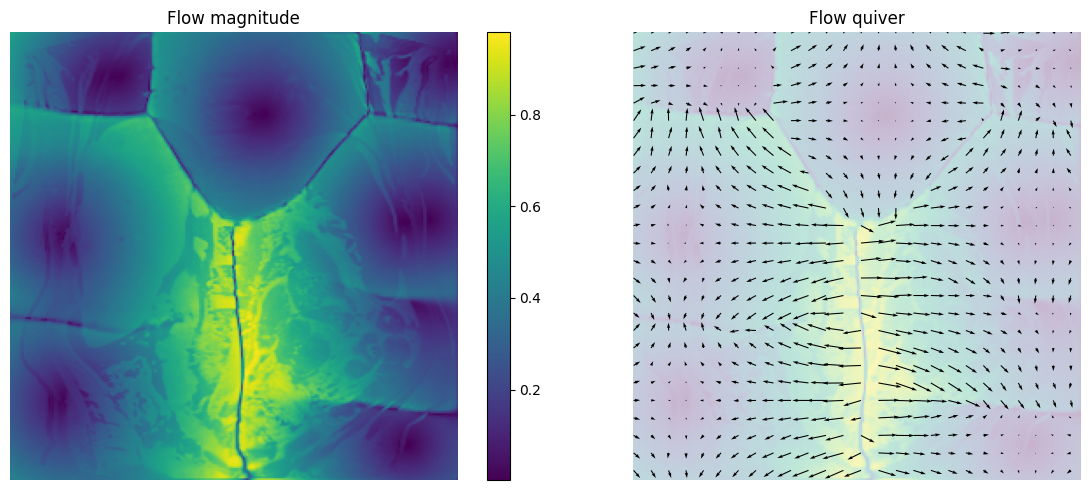

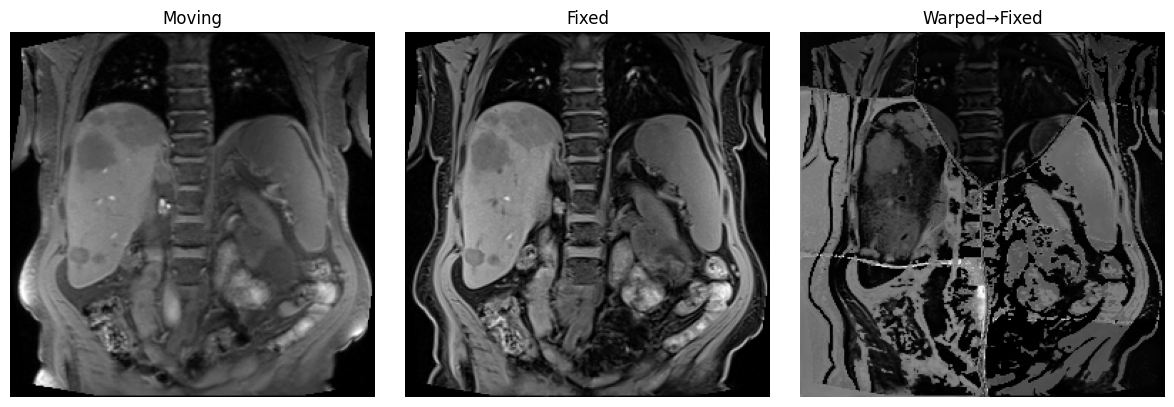

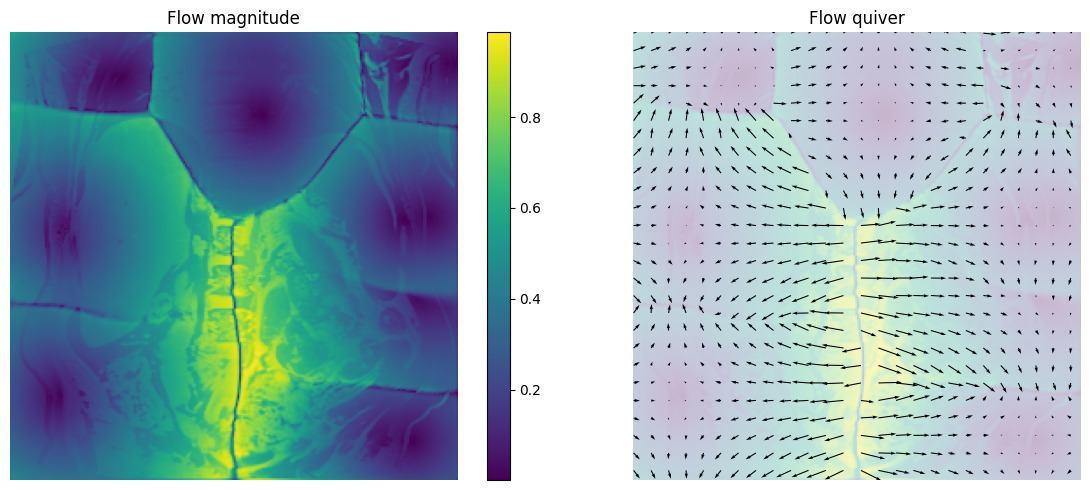

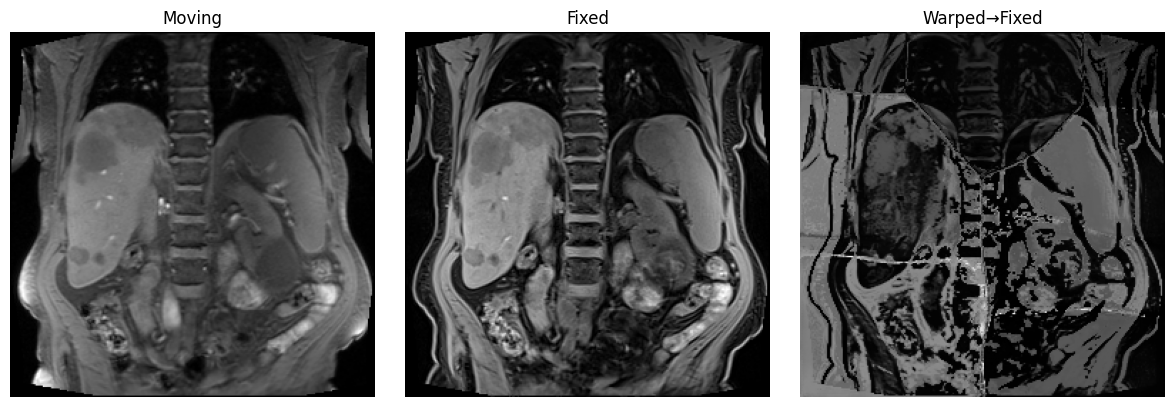

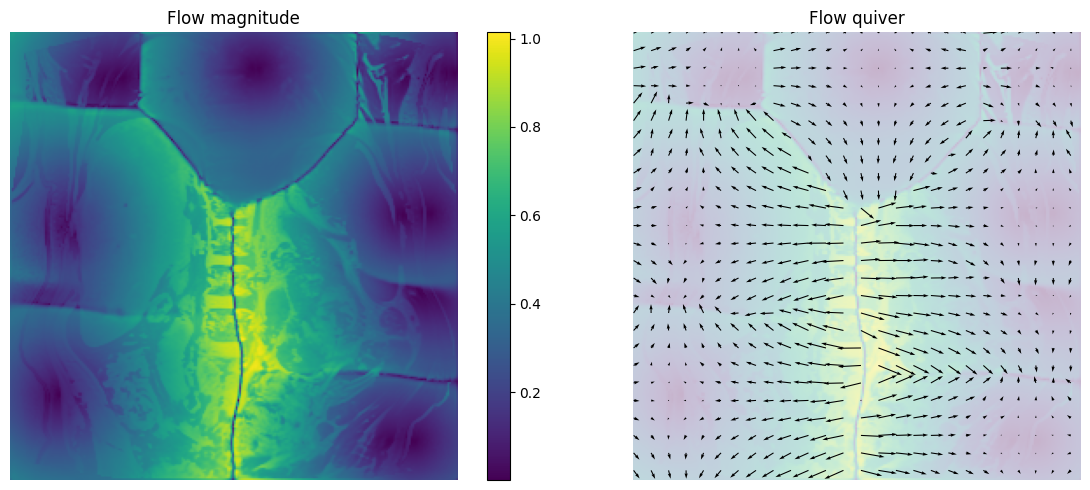

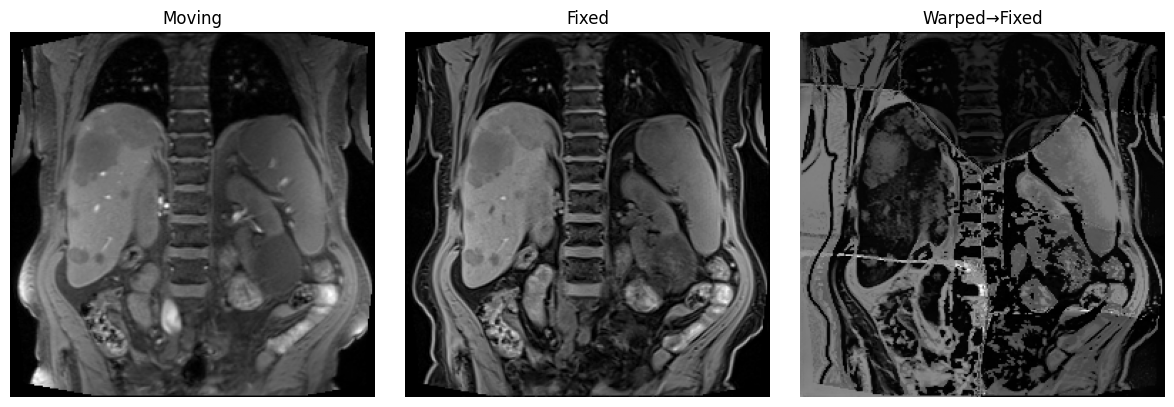

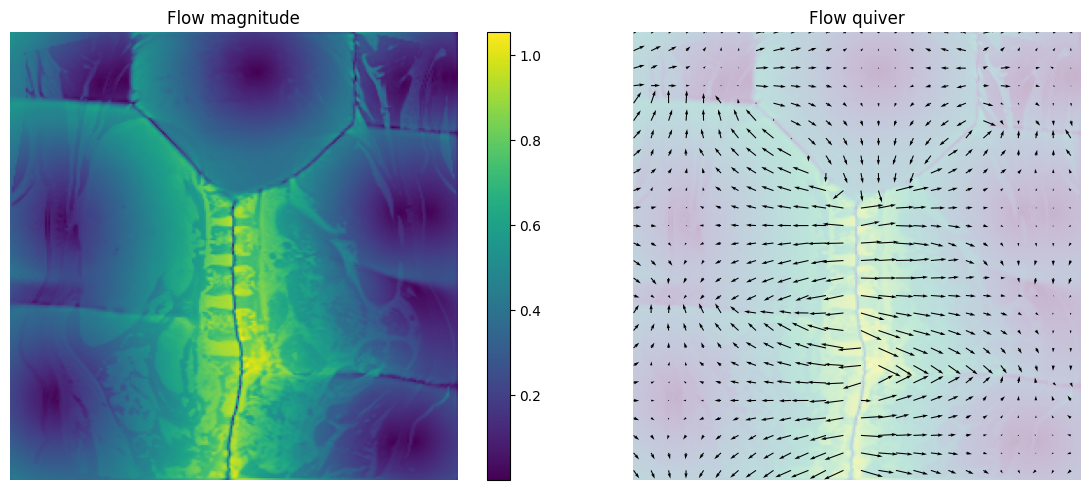

In [5]:
# 1) Single pair + mask (quick visual)
moving = np.load("data/my_data2/test/T1_mapping_fl2d.npy")   # (H,W)
fixed  = np.load("data/my_data2/test/DIXON.npy")    # (H,W)
mask   = np.load("data/my_data2/test/T1_mapping_fl2d_masks.npy")     # (H,W), integers

warped, flow, warped_mask = nb_register_pair(
    checkpoint="outputs/registr_2d/best.pt",
    moving_slice=moving,
    fixed_slice=fixed,
    mask_slice=mask,
    zscore=True,
    visualize=True,
)

# 2) Whole split in-memory (no files written), with previews
warped_all, flows_all = nb_infer_split(
    checkpoint="outputs/registr_2d/best.pt",
    data_root="data/my_data2",
    split="test",
    target="DIXON",
    moving="T1_mapping_fl2d",
    preview=5,
)
